In [7]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import intake
mpl.rcParams['figure.dpi'] = 72

In [8]:
# catalog = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
catalog = "/global/homes/f/feng045/program/hackathon/catalog/NERSC/main.yaml"

# current_location = "online"
current_location = "NERSC"
source = "nicam_gl11"
# source = "icon_d3hp003"
#source = "um_glm_n2560_RAL3p3"
#source = "ifs_tco3999-ng5_rcbmf_cf"
#source = "scream-dkrz"

# zoom = 9
# time = "PT1H"

zoom = 8
# time = "PT1H"
# time = "PT3H"
time = "PT6H"

lats, latN = -20, 20

# cat = intake.open_catalog(catalog)[current_location]

cat = intake.open_catalog(catalog)
ds = cat[source](zoom=zoom, time=time).to_dask()
ds = ds.pipe(egh.attach_coords)
ds 

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 919GB
Dimensions:  (time: 1460, lev: 25, cell: 786432)
Coordinates:
  * lev      (lev) float64 200B 1e+03 975.0 950.0 925.0 ... 20.0 10.0 5.0 1.0
  * time     (time) datetime64[ns] 12kB 2020-03-01T06:00:00 ... 2021-03-01
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    hur      (time, lev, cell) float32 115GB ...
    hus      (time, lev, cell) float32 115GB ...
    qall     (time, lev, cell) float32 115GB ...
    ta       (time, lev, cell) float32 115GB ...
    ua       (time, lev, cell) float32 115GB ...
    va       (time, lev, cell) float32 115GB ...
    wa       (time, lev, cell) float32 115GB ...
    zg       (time, lev, cell) float32 115GB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    comment:      Be careful that definition of time coordinate depends on th...
    history:      Mon May 05 07:23:50 2025: cdo mergetime ./z08/2020/03/z2pre...
    title:        NICAM data output

In [9]:
ds.lev.values

array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  800.,  750.,
        700.,  600.,  500.,  400.,  300.,  250.,  200.,  150.,  100.,
         70.,   50.,   30.,   20.,   10.,    5.,    1.])

In [15]:
ds.wa.attrs

{'grid_mapping': 'healpix', 'long_name': 'velocity w', 'units': 'm/s'}

In [16]:
ds.zg.attrs

{'grid_mapping': 'healpix', 'long_name': 'geopotential height', 'units': 'm'}

In [11]:
cat[source](zoom=zoom, time=time).urlpath

'/global/cfs/cdirs/m4581/gsharing/hackathon/NICAM/NICAM_3d6h_z8.zarr'

In [13]:
# Read 2D data at 3-hourly intervals
ds2d = cat[source](zoom=zoom, time="PT3H").to_dask()
ds2d = ds2d.pipe(egh.attach_coords)
ds2d

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 303GB
Dimensions:    (time: 2920, cell: 786432, bnds: 2)
Coordinates:
    lev        float64 8B 0.0
  * time       (time) datetime64[ns] 23kB 2020-03-01T01:30:00 ... 2021-02-28T...
    crs        int64 8B 0
  * cell       (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    lat        (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon        (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Dimensions without coordinates: bnds
Data variables: (12/29)
    clivi      (time, cell) float32 9GB ...
    clt        (time, cell) float64 18GB ...
    clwvi      (time, cell) float32 9GB ...
    hflsd      (time, cell) float32 9GB ...
    hfssd      (time, cell) float32 9GB ...
    huss       (time, cell) float32 9GB ...
    ...         ...
    rsutcs     (time, cell) float32 9GB ...
    tas        (time, cell) float64 18GB ...
    time_bnds  (time, bnds) datetime64[ns] 47kB ...
    ts         (time, cell) float64 18GB ...
    uas        (time, cell) float64 18GB ...
    vas        (time, cell) float64 18GB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    comment:      Be careful that definition of time coordinate depends on th...
    history:      Fri Mar 07 10:19:36 2025: cdo mergetime ./z08/2020/03/3hour...
    title:        NICAM data output

In [17]:
ds2d.pr.attrs

{'grid_mapping': 'healpix', 'long_name': 'precipitation', 'units': 'kg/m2/s'}

In [18]:
ds2d.prw.attrs

{'grid_mapping': 'healpix',
 'long_name': 'water vapor path (precipitable water)',
 'units': 'kg/m2'}

In [19]:
# zarr_file = '/pscratch/sd/w/wcmca1/hackathon/NICAM/NICAM_2d1h_z9.zarr'

# Read zomm 8 data
ds8 = cat[source](zoom=8, time=time).to_dask()
ds8 = ds8.pipe(egh.attach_coords)
ds8

ds7 = cat[source](zoom=7, time=time).to_dask()
ds7 = ds7.pipe(egh.attach_coords)

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consisten

In [15]:
z9_shifted = f"/pscratch/sd/w/wcmca1/hackathon/NICAM/shifted/NICAM_2d1h_z9_shifted.zarr"

ds9 = xr.open_zarr(z9_shifted, consolidated=True)
ds9

<xarray.Dataset> Size: 882GB
Dimensions:  (cell: 3145728, time: 8759)
Coordinates:
  * cell     (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    crs      int64 8B ...
    lat      (cell) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    lev      float64 8B ...
    lon      (cell) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
  * time     (time) datetime64[ns] 70kB 2020-03-01T01:00:00 ... 2021-02-28T23...
Data variables:
    pr       (time, cell) float32 110GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    psl      (time, cell) float32 110GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    rlut     (time, cell) float32 110GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    rsut     (time, cell) float32 110GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    uas      (time, cell) float64 220GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    vas      (time, cell) float64 220GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>

In [16]:
ds8.time[0:10], ds9.time[0:10]

(<xarray.DataArray 'time' (time: 10)> Size: 80B
 array(['2020-03-01T01:00:00.000000000', '2020-03-01T02:00:00.000000000',
        '2020-03-01T03:00:00.000000000', '2020-03-01T04:00:00.000000000',
        '2020-03-01T05:00:00.000000000', '2020-03-01T06:00:00.000000000',
        '2020-03-01T07:00:00.000000000', '2020-03-01T08:00:00.000000000',
        '2020-03-01T09:00:00.000000000', '2020-03-01T10:00:00.000000000'],
       dtype='datetime64[ns]')
 Coordinates:
     lev      float64 8B 0.0
   * time     (time) datetime64[ns] 80B 2020-03-01T01:00:00 ... 2020-03-01T10:...
     crs      int64 8B 0
 Attributes:
     axis:           T
     long_name:      Time
     standard_name:  time,
 <xarray.DataArray 'time' (time: 10)> Size: 80B
 array(['2020-03-01T01:00:00.000000000', '2020-03-01T02:00:00.000000000',
        '2020-03-01T03:00:00.000000000', '2020-03-01T04:00:00.000000000',
        '2020-03-01T05:00:00.000000000', '2020-03-01T06:00:00.000000000',
        '2020-03-01T07:00:00.000000000', 

In [20]:
common_times_z89 = sorted(set(ds8['time'].values).intersection(set(ds9['time'].values)))
len(common_times_z89)

8759

In [22]:
common_times_z79 = sorted(set(ds7['time'].values).intersection(set(ds9['time'].values)))
len(common_times_z79)

8759

In [23]:
ds9.time[-1]

<xarray.DataArray 'time' ()> Size: 8B
array('2021-02-28T23:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    crs      int64 8B ...
    lev      float64 8B ...
    time     datetime64[ns] 8B 2021-02-28T23:00:00

In [9]:
ds.pr.attrs

{'grid_mapping': 'healpix', 'long_name': 'precipitation', 'units': 'kg/m2/s'}

In [11]:
ds.time[0:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2020-03-01T00:30:00.000000000', '2020-03-01T01:00:00.000000000',
       '2020-03-01T01:30:00.000000000', '2020-03-01T02:00:00.000000000',
       '2020-03-01T02:30:00.000000000', '2020-03-01T03:00:00.000000000',
       '2020-03-01T03:30:00.000000000', '2020-03-01T04:00:00.000000000',
       '2020-03-01T04:30:00.000000000', '2020-03-01T05:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    lev      float64 8B 0.0
  * time     (time) datetime64[ns] 80B 2020-03-01T00:30:00 ... 2020-03-01T05:...
    crs      int64 8B 0
Attributes:
    axis:           T
    long_name:      Time
    standard_name:  time

## Handling Staggered Time Coordinates

`pr` and `rlut` are stored on staggered time grids:
- **pr**: valid at :30 (e.g., 10:30, 11:30, 12:30, ...)
- **rlut**: valid at :00 (e.g., 11:00, 12:00, 13:00, ...)

To visualize both variables together, we need to either:
1. Select times that are offset by 30 minutes
2. Use `method='nearest'` with `.sel()` to find the nearest valid timestep
3. Filter to only the valid timesteps for each variable

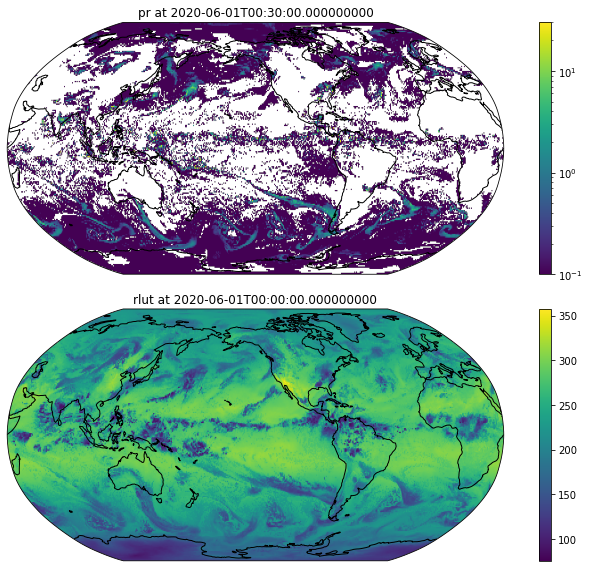

Note: These are from different times, 30 minutes apart!
  pr timestamp:   2020-06-01T00:30:00.000000000
  rlut timestamp: 2020-06-01T00:00:00.000000000


In [12]:
# Plot pr and rlut from nearby times (30 minutes apart)
# Use a time where rlut has data (:00)
rlut_time = '2020-06-01T00:00'
# Use a time 30 minutes before or after for pr
pr_time = '2020-06-01T00:30'

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8), 
                                subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})

def egh_plot(data, ax, title=None, **kwargs):
    if title:
        ax.set_title(title)
    else:
        ax.set_title(data.name)
    ax.set_global()
    im = egh.healpix_show(data, ax=ax, **kwargs)
    plt.colorbar(im, ax=ax)
    ax.coastlines()

# Plot pr at :30
pr_data = ds.pr.sel(time=pr_time, method='nearest')
egh_plot(pr_data * 3600, ax=ax0, 
         title=f'pr at {pr_data.time.values}',
         norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30))

# Plot rlut at :00
rlut_data = ds.rlut.sel(time=rlut_time, method='nearest')
egh_plot(rlut_data, ax=ax1,
         title=f'rlut at {rlut_data.time.values}')

plt.tight_layout()
plt.show()

print(f"Note: These are from different times, 30 minutes apart!")
print(f"  pr timestamp:   {pr_data.time.values}")
print(f"  rlut timestamp: {rlut_data.time.values}")

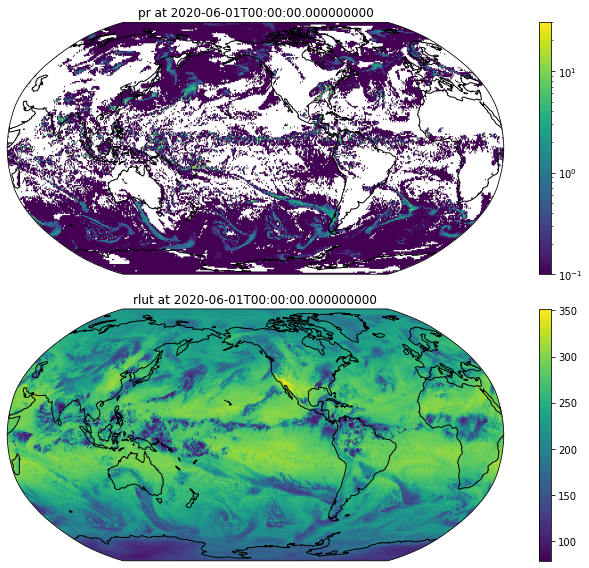

Note: These are from different times, 30 minutes apart!
  pr timestamp:   2020-06-01T00:00:00.000000000
  rlut timestamp: 2020-06-01T00:00:00.000000000


In [13]:
# Plot pr and rlut from nearby times (30 minutes apart)
# Use a time where rlut has data (:00)
rlut_time = '2020-06-01T00:00'
# Use a time 30 minutes before or after for pr
pr_time = '2020-06-01T00:00'

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8), 
                                subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})

# Plot pr at :00
pr_data = ds8.pr.sel(time=pr_time, method='nearest')
egh_plot(pr_data * 3600, ax=ax0, 
         title=f'pr at {pr_data.time.values}',
         norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30))

# Plot rlut at :00
rlut_data = ds8.rlut.sel(time=rlut_time, method='nearest')
egh_plot(rlut_data, ax=ax1,
         title=f'rlut at {rlut_data.time.values}')

plt.tight_layout()
plt.show()

print(f"Note: These are from different times, 30 minutes apart!")
print(f"  pr timestamp:   {pr_data.time.values}")
print(f"  rlut timestamp: {rlut_data.time.values}")

## Unifying Time Coordinates (Lazy Evaluation)

We'll align both variables to the same time coordinate by:
1. Keep `rlut` at :00 timestamps
2. Shift `pr` from :30 to :00 (same hour)
3. Combine into a unified dataset with half the timesteps

This uses lazy evaluation - no data is loaded until needed!

In [9]:
ds.time.isel(time=0)

<xarray.DataArray 'time' ()> Size: 8B
array('2020-03-01T00:30:00.000000000', dtype='datetime64[ns]')
Coordinates:
    lev      float64 8B 0.0
    time     datetime64[ns] 8B 2020-03-01T00:30:00
    crs      int64 8B 0
Attributes:
    axis:           T
    long_name:      Time
    standard_name:  time

In [10]:
# Step 1: Extract rlut at :00 timestamps (odd indices: 1, 3, 5, ...)
# These will be our unified time coordinates
rlut_aligned = ds.rlut.isel(time=slice(1, None, 2))

print(f"rlut original times: {len(ds.rlut.time)}")
print(f"rlut aligned times: {len(rlut_aligned.time)}")
print(f"First 5 rlut times: {rlut_aligned.time.values[:5]}")

# Step 2: Extract pr at :30 timestamps 
# Need to start at index 2 (not 0) to align with rlut that starts at index 1
# Index 0 is 00:30 -> would shift to 00:00 (no matching rlut)
# Index 2 is 01:30 -> will shift to 01:00 (matches rlut at index 1)
pr_30min = ds.pr.isel(time=slice(2, None, 2))

print(f"\npr original times: {len(ds.pr.time)}")
print(f"pr at :30 times: {len(pr_30min.time)}")
print(f"First 5 pr times (before shifting): {pr_30min.time.values[:5]}")
print(f"Note: Skipping first pr timestep (00:30) which has no matching rlut")

rlut original times: 17520
rlut aligned times: 8760
First 5 rlut times: ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000' '2020-03-01T04:00:00.000000000'
 '2020-03-01T05:00:00.000000000']

pr original times: 17520
pr at :30 times: 8759
First 5 pr times (before shifting): ['2020-03-01T01:30:00.000000000' '2020-03-01T02:30:00.000000000'
 '2020-03-01T03:30:00.000000000' '2020-03-01T04:30:00.000000000'
 '2020-03-01T05:30:00.000000000']
Note: Skipping first pr timestep (00:30) which has no matching rlut


In [11]:
# Step 3: Shift pr time coordinate from :30 to :00 (subtract 30 minutes)
# Use assign_coords to change the time coordinate WITHOUT loading data

# Create new time coordinate: shift back 30 minutes
new_time = pr_30min.time.values - pd.Timedelta(minutes=30)

# Assign new time coordinate (lazy operation!)
pr_aligned = pr_30min.assign_coords(time=new_time)

# Step 3.5: Ensure both have the same length
# Trim rlut to match pr length (they might differ by 1 if dataset has odd total length)
min_len = min(len(pr_aligned.time), len(rlut_aligned.time))
pr_aligned = pr_aligned.isel(time=slice(0, min_len))
rlut_aligned = rlut_aligned.isel(time=slice(0, min_len))

print(f"First 5 pr times (after shifting to :00): {pr_aligned.time.values[:5]}")
print(f"\nVerify alignment:")
print(f"  rlut times ({len(rlut_aligned.time)}): {rlut_aligned.time.values[:3]}")
print(f"  pr times ({len(pr_aligned.time)}):   {pr_aligned.time.values[:3]}")
print(f"  Match: {np.all(rlut_aligned.time.values == pr_aligned.time.values)}")

First 5 pr times (after shifting to :00): ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000' '2020-03-01T04:00:00.000000000'
 '2020-03-01T05:00:00.000000000']

Verify alignment:
  rlut times (8759): ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000']
  pr times (8759):   ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000']
  Match: True


In [12]:
# Step 4: Create unified dataset with aligned time coordinates
# Merge both variables into a single dataset (still lazy!)
ds_unified = xr.Dataset({
    'pr': pr_aligned,
    'rlut': rlut_aligned,
})

print(f"Unified dataset created!")
print(f"  Original dataset: {len(ds.time)} timesteps")
print(f"  Unified dataset:  {len(ds_unified.time)} timesteps (reduced by half)")
print(f"\nDataset structure:")
print(ds_unified)

Unified dataset created!
  Original dataset: 17520 timesteps
  Unified dataset:  8759 timesteps (reduced by half)

Dataset structure:
<xarray.Dataset> Size: 221GB
Dimensions:  (cell: 3145728, time: 8759)
Coordinates:
    lev      float64 8B 0.0
    crs      int64 8B 0
  * cell     (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    lat      (cell) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
    lon      (cell) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
  * time     (time) datetime64[ns] 70kB 2020-03-01T01:00:00 ... 2021-02-28T23...
Data variables:
    pr       (time, cell) float32 110GB ...
    rlut     (time, cell) float32 110GB ...


In [13]:
# # Check that it's still lazy (dask arrays) - use safer check
# import dask.array as da
# print(f"\nChecking if data is still lazy (dask arrays):")
# print(f"  pr is dask array: {isinstance(ds_unified.pr.data, da.Array)}")
# print(f"  rlut is dask array: {isinstance(ds_unified.rlut.data, da.Array)}")
# if isinstance(ds_unified.pr.data, da.Array):
#     print(f"  pr chunks: {ds_unified.pr.data.chunksize}")
#     print(f"  rlut chunks: {ds_unified.rlut.data.chunksize}")
# print("\n✓ No data has been loaded into memory yet!")

Plotting unified data at 2020-06-01T00:00:
  pr time: 2020-06-01T00:00:00.000000000
  rlut time: 2020-06-01T00:00:00.000000000
  Times match: True


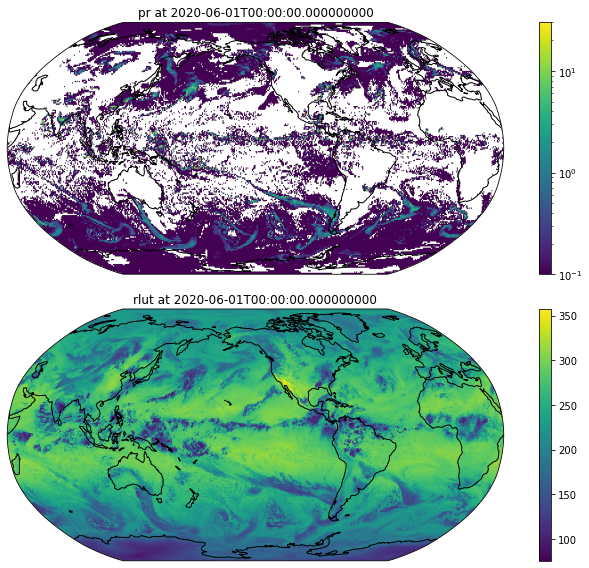

In [14]:
# Step 5: Test the unified dataset by plotting a single timestep
# Only this one timestep will be fetched from the object store
test_time = '2020-06-01T00:00'

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8), 
                                subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})

def egh_plot(data, ax, title=None, **kwargs):
    if title:
        ax.set_title(title)
    else:
        ax.set_title(data.name)
    ax.set_global()
    im = egh.healpix_show(data, ax=ax, **kwargs)
    plt.colorbar(im, ax=ax)
    ax.coastlines()

# Now both variables are at the same time!
pr_data = ds_unified.pr.sel(time=test_time)
rlut_data = ds_unified.rlut.sel(time=test_time)

print(f"Plotting unified data at {test_time}:")
print(f"  pr time: {pr_data.time.values}")
print(f"  rlut time: {rlut_data.time.values}")
print(f"  Times match: {pr_data.time.values == rlut_data.time.values}")

egh_plot(pr_data * 3600, ax=ax0, 
         title=f'pr at {pr_data.time.values}',
         norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30))

egh_plot(rlut_data, ax=ax1,
         title=f'rlut at {rlut_data.time.values}')

plt.tight_layout()
plt.show()

In [15]:
# Check time patterns for all variables in the dataset
print("Checking which timesteps have valid data for each variable:")
print("=" * 90)

# Check a representative sample of timesteps
test_indices = [0, 1, 2, 3, 4, 5]  # First few timesteps

# Build the header
header = f"{'Index':<6} {'Time':<30}"
for var in ds.data_vars:
    header += f" {var:<8}"
print(header)
print("-" * 90)

# Check each timestep
for idx in test_indices:
    time_val = ds.time.isel(time=idx).values
    row = f"{idx:<6} {str(time_val):<30}"
    
    for var in ds.data_vars:
        count = np.count_nonzero(~np.isnan(ds[var].isel(time=idx).values))
        has_data = "✓" if count > 0 else "✗"
        row += f" {has_data:<8}"
    print(row)

# Summarize the pattern
print("\n" + "=" * 90)
print("Summary of time patterns:")
print("-" * 90)

vars_at_30 = []
vars_at_00 = []

for var in ds.data_vars:
    # Check if variable has data at index 0 (:30) or index 1 (:00)
    count_at_0 = np.count_nonzero(~np.isnan(ds[var].isel(time=0).values))
    count_at_1 = np.count_nonzero(~np.isnan(ds[var].isel(time=1).values))
    
    if count_at_0 > 0:
        vars_at_30.append(var)
        print(f"  {var:<10} → Valid at :30 timestamps (index 0, 2, 4, ...)")
    elif count_at_1 > 0:
        vars_at_00.append(var)
        print(f"  {var:<10} → Valid at :00 timestamps (index 1, 3, 5, ...)")
    else:
        print(f"  {var:<10} → No valid data found in first timesteps!")

print("\n" + "=" * 90)
print("Conclusion:")
print(f"  Variables at :30 (like pr):   {vars_at_30}")
print(f"  Variables at :00 (like rlut): {vars_at_00}")
print("\n✓ All variables follow one of two patterns - ready for unification!")

Checking which timesteps have valid data for each variable:
Index  Time                           pr       psl      rlut     rsut     uas      vas     
------------------------------------------------------------------------------------------
0      2020-03-01T00:30:00.000000000  ✓        ✗        ✗        ✗        ✗        ✗       
0      2020-03-01T00:30:00.000000000  ✓        ✗        ✗        ✗        ✗        ✗       
1      2020-03-01T01:00:00.000000000  ✗        ✓        ✓        ✓        ✓        ✓       
1      2020-03-01T01:00:00.000000000  ✗        ✓        ✓        ✓        ✓        ✓       
2      2020-03-01T01:30:00.000000000  ✓        ✗        ✗        ✗        ✗        ✗       
2      2020-03-01T01:30:00.000000000  ✓        ✗        ✗        ✗        ✗        ✗       
3      2020-03-01T02:00:00.000000000  ✗        ✓        ✓        ✓        ✓        ✓       
3      2020-03-01T02:00:00.000000000  ✗        ✓        ✓        ✓        ✓        ✓       
4      2020-03-01T02:

In [16]:
# Create a helper function to build unified datasets easily
def create_unified_dataset(ds, vars_at_30min, vars_at_00min):
    """
    Create a unified dataset with aligned time coordinates.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Original dataset with staggered times
    vars_at_30min : list
        Variables that have data at :30 timestamps (to be shifted)
    vars_at_00min : list
        Variables that have data at :00 timestamps (kept as-is)
    
    Returns:
    --------
    xarray.Dataset with unified time coordinate
    
    Note:
    -----
    The first timestep of the original dataset (index 0) is typically :30,
    so we skip it to align with :00 variables that start at index 1.
    """
    
    unified_vars = {}
    
    # Process variables at :30 (shift to :00)
    # Start at index 2 (not 0) to align with :00 variables at index 1
    for var in vars_at_30min:
        var_30 = ds[var].isel(time=slice(2, None, 2))
        new_time = var_30.time.values - pd.Timedelta(minutes=30)
        unified_vars[var] = var_30.assign_coords(time=new_time)
    
    # Process variables at :00 (keep as-is)
    for var in vars_at_00min:
        unified_vars[var] = ds[var].isel(time=slice(1, None, 2))
    
    # Ensure all variables have the same length (trim to minimum)
    # This handles edge case where total timesteps might cause length mismatch
    min_len = min(len(unified_vars[var].time) for var in unified_vars)
    for var in unified_vars:
        unified_vars[var] = unified_vars[var].isel(time=slice(0, min_len))
    
    return xr.Dataset(unified_vars)

In [17]:
# Example usage:
ds_unified_full = create_unified_dataset(
    ds,
    vars_at_30min=['pr'],  # Add more if they follow the same pattern
    vars_at_00min=['rlut', 'uas', 'vas']  # Add more if they follow the same pattern
)

print(f"Full unified dataset created with {len(ds_unified_full.data_vars)} variables:")
for var in ds_unified_full.data_vars:
    print(f"  - {var}")
print(f"\nTimesteps: {len(ds_unified_full.time)} (from {ds_unified_full.time.values[0]} to {ds_unified_full.time.values[-1]})")
print(f"\nFirst 3 timestamps (all should match):")
for var in ds_unified_full.data_vars:
    print(f"  {var}: {ds_unified_full[var].time.values[:3]}")

# Verify all variables have the same time coordinate
all_times = [ds_unified_full[var].time.values for var in ds_unified_full.data_vars]
all_match = all(np.array_equal(all_times[0], t) for t in all_times[1:])
print(f"\n✓ All variables have matching time coordinates: {all_match}")

Full unified dataset created with 4 variables:
  - pr
  - rlut
  - uas
  - vas

Timesteps: 8759 (from 2020-03-01T01:00:00.000000000 to 2021-02-28T23:00:00.000000000)

First 3 timestamps (all should match):
  pr: ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000']
  rlut: ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000']
  uas: ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000']
  vas: ['2020-03-01T01:00:00.000000000' '2020-03-01T02:00:00.000000000'
 '2020-03-01T03:00:00.000000000']

✓ All variables have matching time coordinates: True


In [18]:
ds.uas.attrs

{'grid_mapping': 'healpix',
 'long_name': '10m velocity u',
 'units': 'm/s',
 'var_force_to_set_valid_max': 300.0,
 'var_force_to_set_valid_min': -300.0}